In [3]:
import pandas as pd

### Chargement des données

Données : https://github.com/CVidalG/Index-of-Armenian-Manuscripts

In [5]:
file_path = "/Users/nostradamus/Calfa/GitOpenCalfa/Index-Armenian-Manuscripts/Index-of-Armenian-Manuscripts/index.tsv"
df = pd.read_csv(file_path, sep="\t")

In [6]:
df.head()

,ID,Cat. Number,Location,Country,Town,Permalink,Digital Library,Support,Date,Pages,Size,Title,Note,Genre,IIIF Manifest
0,M6200,M6200,Matenadaran,Armenia,Yerevan,http://daten.digitale-sammlungen.de/~db/0004/b...,Bayerische Staatsbibliothek,Paper,887,NaN,NaN,Gospel Book,NaN,Bible,NaN
1,M2364,M2364,Matenadaran,Armenia,Yerevan,https://archive.org/embed/lvangilearmn00macl,archive.org,Paper,NaN,NaN,NaN,L'Évangile arménien : édition phototypique du ...,NaN,Bible,NaN
2,M3461,M3461,Matenadaran,Armenia,Yerevan,http://micro5.mscc.huji.ac.il/~armenia/website...,Hebrew University of Jerusalem,NaN,1662,44 images,NaN,The Penitence of Adam,Inc.,Hagiography,NaN
3,SIN87,Georgian Manuscripts 87,"St. Catherine's Monastery, Mount Sinai",Egypt,Sinaï,https://www.loc.gov/item/00279387247-ms,Library of Congress,Paper,NaN,197 images,NaN,Aristotle's Categoriae with Commentary (Armenian),Ms.,Philosophy,NaN
4,MAF50,50,Musée Arménien de France - IRHT,France,Paris,https://arca.irht.cnrs.fr/ark:/63955/md24wh249n0k,ARCA,Parchment,1342,354 folios,13 x 9 cm,Liturgical books (Eastern Christian),Ms.,Liturgy,https://api.irht.cnrs.fr/ark:/63955/f5lzamu0bf...


### Etude qualitative du dataset / recherche de corrélations sans a priori

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
df_clean = df.copy()

In [9]:
# Extraction valeurs numériques
df_clean[['Start Year', 'End Year']] = df_clean['Date'].str.extract(r'(\d{4})-?(\d{4})?')
df_clean['Start Year'] = pd.to_numeric(df_clean['Start Year'], errors='coerce')
df_clean['End Year'] = pd.to_numeric(df_clean['End Year'], errors='coerce')

In [10]:
df_clean['End Year'].fillna(df_clean['Start Year'], inplace=True)

# Conversion en numérique
df_clean['Pages'] = df_clean['Pages'].str.extract(r'(\d+)').astype(float)

# Conversion dimensions manuscrit
df_clean[['Width', 'Height', 'Depth']] = df_clean['Size'].str.extract(r'([\d.]+) x ([\d.]+) x ([\d.]+)')
df_clean[['Width', 'Height', 'Depth']] = df_clean[['Width', 'Height', 'Depth']].astype(float)

/var/folders/x7/s2ydkrpn7xb7jfnym9v1gzf80000gn/T/ipykernel_28741/819847766.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['End Year'].fillna(df_clean['Start Year'], inplace=True)


In [13]:
# Transformation des variables qualitatives en index
df_clean['Support'] = df_clean['Support'].astype('category').cat.codes
df_clean['Country'] = df_clean['Country'].astype('category').cat.codes
df_clean['Location'] = df_clean['Location'].astype('category').cat.codes
df_clean['Genre'] = df_clean['Location'].astype('category').cat.codes

In [ ]:
# Sélection de colonnes pour les corrélations
corr_columns = ['Start Year', 'End Year', 'Pages', 'Width', 'Height', 'Depth', 'Support', 'Country', 'Location', 'Genre']
df_corr = df_clean[corr_columns].dropna()

# Matrice de corrélations
corr_matrix = df_corr.corr(method='spearman')

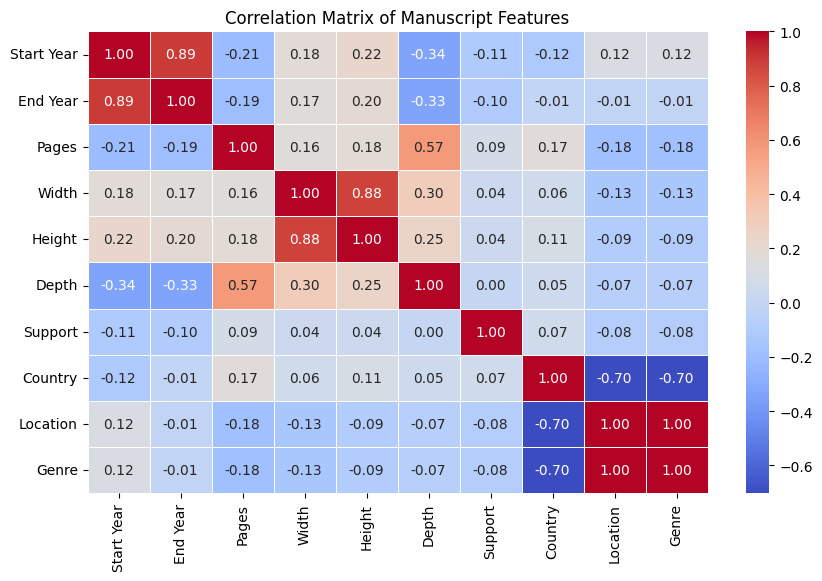

In [31]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Manuscript Features")
plt.show()


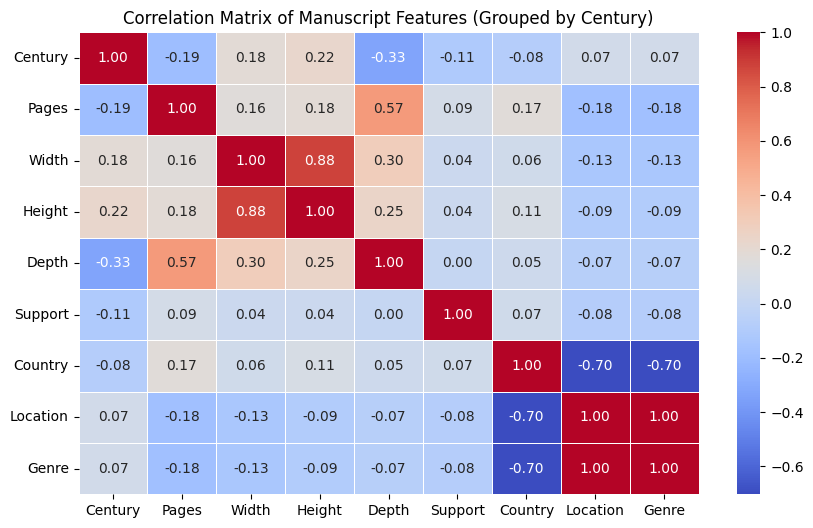

In [17]:
def get_century(year):
    if pd.isna(year):
        return None
    return (int(year) // 100 + 1)  


df_clean['Century'] = df_clean['Start Year'].apply(get_century)
df_clean['Century'] = df_clean['Century'].astype('category')

corr_columns = ['Century', 'Pages', 'Width', 'Height', 'Depth', 'Support', 'Country', 'Location', 'Genre']
df_corr = df_clean[corr_columns].dropna()

df_corr['Century'] = df_corr['Century'].cat.codes

corr_matrix_century = df_corr.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix_century, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Manuscript Features (Grouped by Century)")
plt.show()


### Viz de tendances

/var/folders/x7/s2ydkrpn7xb7jfnym9v1gzf80000gn/T/ipykernel_28741/3378210789.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_size_trend = df_clean.groupby('Century')[['Width', 'Height', 'Depth']].mean().reset_index()


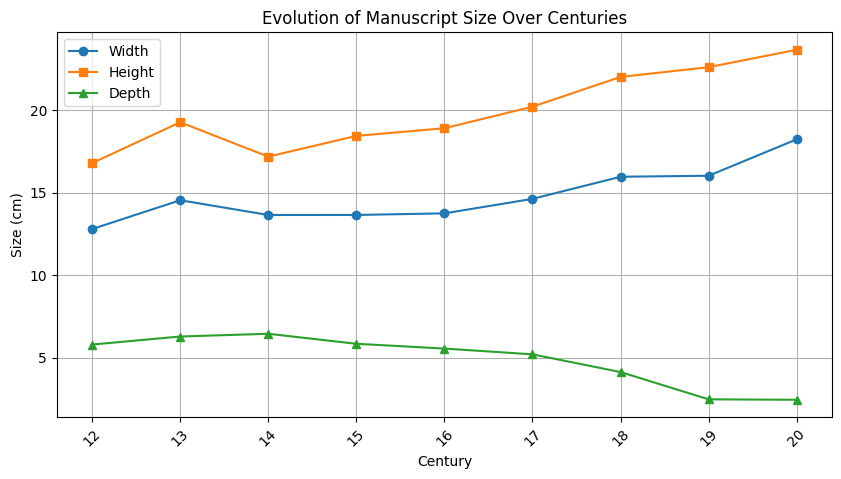

In [18]:
# Visualisation de la taille des manuscrits à travers les sièclescenturies

df_size_trend = df_clean.groupby('Century')[['Width', 'Height', 'Depth']].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(df_size_trend['Century'], df_size_trend['Width'], marker='o', linestyle='-', label="Width")
plt.plot(df_size_trend['Century'], df_size_trend['Height'], marker='s', linestyle='-', label="Height")
plt.plot(df_size_trend['Century'], df_size_trend['Depth'], marker='^', linestyle='-', label="Depth")
plt.xlabel("Century")
plt.ylabel("Size (cm)")
plt.title("Evolution of Manuscript Size Over Centuries")
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.show()

/var/folders/x7/s2ydkrpn7xb7jfnym9v1gzf80000gn/T/ipykernel_28741/413911601.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_pages_trend = df_clean.groupby('Century')['Pages'].mean().reset_index()


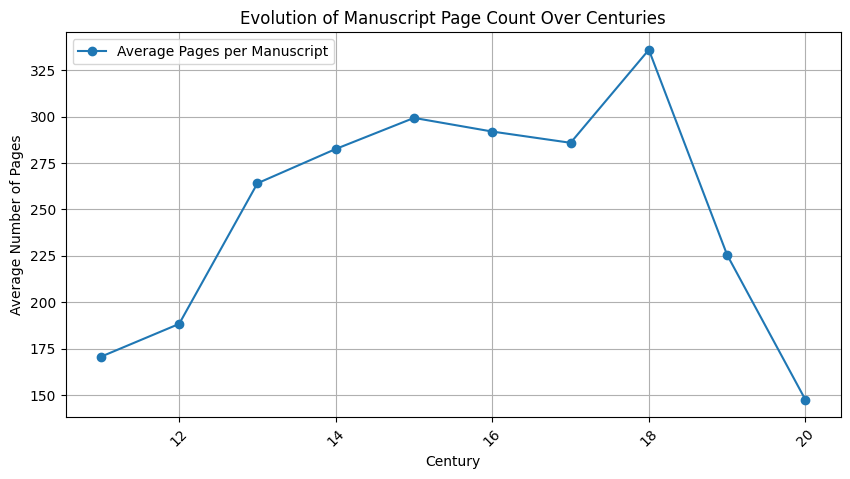

In [19]:
# Visualisation du nombre de pages à travers les siècles

df_pages_trend = df_clean.groupby('Century')['Pages'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(df_pages_trend['Century'], df_pages_trend['Pages'], marker='o', linestyle='-', label="Average Pages per Manuscript")
plt.xlabel("Century")
plt.ylabel("Average Number of Pages")
plt.title("Evolution of Manuscript Page Count Over Centuries")
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.show()


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

features = ['Pages', 'Width', 'Height', 'Depth', 'Support', 'Country', 'Location']
df_model = df_clean.dropna(subset=['Century'] + features).copy()

df_model['Century_Code'] = df_model['Century'].cat.codes

X = df_model[features]
y_century = df_model['Century_Code']
X_train, X_test, y_train_century, y_test_century = train_test_split(
    X, y_century, test_size=0.2, random_state=42
)

clf = RandomForestClassifier(n_estimators=1000, max_depth=20, random_state=42)
clf.fit(X_train, y_train_century)

y_pred_century = clf.predict(X_test)

accuracy = accuracy_score(y_test_century, y_pred_century)
print("CLASSIFICATION PAR SIÈCLE")
print("="*60)
print(f"Accuracy: {accuracy:.4f}")
print(f"Nombre de manuscrits testés: {len(y_test_century)}")
print(f"\nRapport de classification:\n")
print(classification_report(y_test_century, y_pred_century))

CLASSIFICATION PAR SIÈCLE
Accuracy: 0.5105
Nombre de manuscrits testés: 237

Rapport de classification:

              precision    recall  f1-score   support

           2       1.00      0.40      0.57         5
           3       0.40      0.29      0.33         7
           4       0.00      0.00      0.00         2
           5       0.29      0.15      0.20        13
           6       0.57      0.57      0.57        65
           7       0.53      0.56      0.55        85
           8       0.47      0.55      0.51        49
           9       0.50      0.27      0.35        11

    accuracy                           0.51       237
   macro avg       0.47      0.35      0.39       237
weighted avg       0.52      0.51      0.51       237



### Métriques d'évaluation pour la régression

**MAE (Mean Absolute Error)** : Erreur absolue moyenne
- Moyenne des erreurs en valeur absolue
- Interprétation directe : en moyenne, le modèle se trompe de X années
- Formule : $MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$

**RMSE (Root Mean Squared Error)** : Racine de l'erreur quadratique moyenne
- Plus sensible aux grandes erreurs que la MAE
- Pénalise davantage les prédictions très éloignées
- Formule : $RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$

**R² (Coefficient de détermination)** : Qualité de l'ajustement
- Proportion de la variance expliquée par le modèle
- Valeurs entre -∞ et 1 (1 = prédiction parfaite, 0 = modèle équivalent à la moyenne)
- Formule : $R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df_reg = df_clean.dropna(subset=['Start Year'] + features).copy()

X_reg = df_reg[features]
y_year = df_reg['Start Year']

X_train_reg, X_test_reg, y_train_year, y_test_year = train_test_split(
    X_reg, y_year, test_size=0.2, random_state=42
)

print("PRÉPARATION DES DONNÉES")
print("="*60)
print(f"Nombre de manuscrits d'entraînement: {len(X_train_reg)}")
print(f"Nombre de manuscrits de test: {len(X_test_reg)}")
print(f"Plage d'années: {int(y_year.min())} - {int(y_year.max())}")

PRÉPARATION DES DONNÉES
Nombre de manuscrits d'entraînement: 944
Nombre de manuscrits de test: 237
Plage d'années: 1123 - 1999


### Régression linéaire

**Principe** : La régression linéaire cherche à modéliser la relation entre les variables explicatives (features) et la variable cible (l'année) par une combinaison linéaire.

**Modèle mathématique** :
$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_7 x_7$$

Où :
- $\hat{y}$ = année prédite
- $\beta_0$ = intercept (ordonnée à l'origine)
- $\beta_1, ..., \beta_7$ = coefficients pour chaque feature
- $x_1, ..., x_7$ = les 7 features : Pages, Width, Height, Depth, Support, Country, Location

**Dans notre cas** :
- Nous utilisons **toutes les 7 features** disponibles
- Le modèle apprend les coefficients optimaux en minimisant l'erreur quadratique moyenne
- Chaque feature contribue de manière **linéaire** à la prédiction

**Exemple concret** :
Année prédite = β₀ + (β₁ × Pages) + (β₂ × Width) + (β₃ × Height) + (β₄ × Depth) + (β₅ × Support) + (β₆ × Country) + (β₇ × Location)

**Limitation** : La régression linéaire suppose que la relation entre les features et l'année est linéaire, ce qui peut être trop simpliste pour des données historiques complexes.

In [34]:
lr_reg = LinearRegression()
lr_reg.fit(X_train_reg, y_train_year)
y_pred_lr = lr_reg.predict(X_test_reg)

mae_lr = mean_absolute_error(y_test_year, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_year, y_pred_lr))
r2_lr = r2_score(y_test_year, y_pred_lr)

print("RÉGRESSION LINÉAIRE")
print("="*60)
print(f"MAE: {mae_lr:.2f} ans")
print(f"RMSE: {rmse_lr:.2f} ans")
print(f"R² Score: {r2_lr:.4f}")
print()
print("Coefficients du modèle:")
for feature, coef in zip(features, lr_reg.coef_):
    print(f"  {feature:12s}: {coef:+10.2f}")
print(f"  Intercept   : {lr_reg.intercept_:+10.2f}")

RÉGRESSION LINÉAIRE
MAE: 87.95 ans
RMSE: 147.31 ans
R² Score: -0.2020

Coefficients du modèle:
  Pages       :      +0.07
  Width       :      +6.27
  Height      :      +3.60
  Depth       :     -27.21
  Support     :     -27.34
  Country     :      -1.64
  Location    :      +0.54
  Intercept   :   +1678.60


**Interprétation des coefficients** :

Les coefficients représentent l'impact de chaque variable sur l'année prédite :

- **Intercept (1651)** : Année de base du modèle
- **Depth (-27.21)** : Chaque cm d'épaisseur supplémentaire diminue l'année prédite de 27 ans (manuscrits plus épais = plus anciens)
- **Support (-27.34)** : Impact fort du type de support
- **Width (+6.27)** et **Height (+3.60)** : Les manuscrits plus grands seraient plus récents
- **Pages (+0.07)** : Impact très faible du nombre de pages
- **Location (+0.54)** et **Country (-1.64)** : Impact géographique modéré

**Problème** : Le R² négatif (-0.20) indique que ce modèle linéaire est **moins performant** que simplement prédire la moyenne des années. Les relations ne sont pas linéaires.

### Random Forest Regressor

In [39]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_split=5, random_state=42)
rf_reg.fit(X_train_reg, y_train_year)
y_pred_rf = rf_reg.predict(X_test_reg)

mae_rf = mean_absolute_error(y_test_year, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_year, y_pred_rf))
r2_rf = r2_score(y_test_year, y_pred_rf)

print("RANDOM FOREST REGRESSOR")
print("="*60)
print(f"MAE: {mae_rf:.2f} ans")
print(f"RMSE: {rmse_rf:.2f} ans")
print(f"R² Score: {r2_rf:.4f}")

RANDOM FOREST REGRESSOR
MAE: 73.51 ans
RMSE: 100.55 ans
R² Score: 0.4400


### Comparaison des modèles de régression

In [31]:
comparison = pd.DataFrame({
    'Modèle': ['Régression Linéaire', 'Random Forest'],
    'MAE (ans)': [mae_lr, mae_rf],
    'RMSE (ans)': [rmse_lr, rmse_rf],
    'R²': [r2_lr, r2_rf]
})

comparison = comparison.sort_values('MAE (ans)')
print(comparison.to_string(index=False))
print()
print(f"Meilleur modèle: {comparison.iloc[0]['Modèle']}")
print(f"Erreur moyenne: ±{comparison.iloc[0]['MAE (ans)']:.0f} ans")

             Modèle  MAE (ans)  RMSE (ans)        R²
      Random Forest  80.362625  108.634454  0.346279
Régression Linéaire  89.315569  145.788504 -0.177345

Meilleur modèle: Random Forest
Erreur moyenne: ±80 ans


In [32]:
feature_importance_rf = pd.DataFrame({
    'Feature': features,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=False)

print("IMPORTANCE DES FEATURES")
print("="*60)
print(feature_importance_rf.to_string(index=False))

IMPORTANCE DES FEATURES
Feature  Importance
  Depth    0.374811
 Height    0.271143
  Pages    0.193735
  Width    0.152318
Support    0.007993


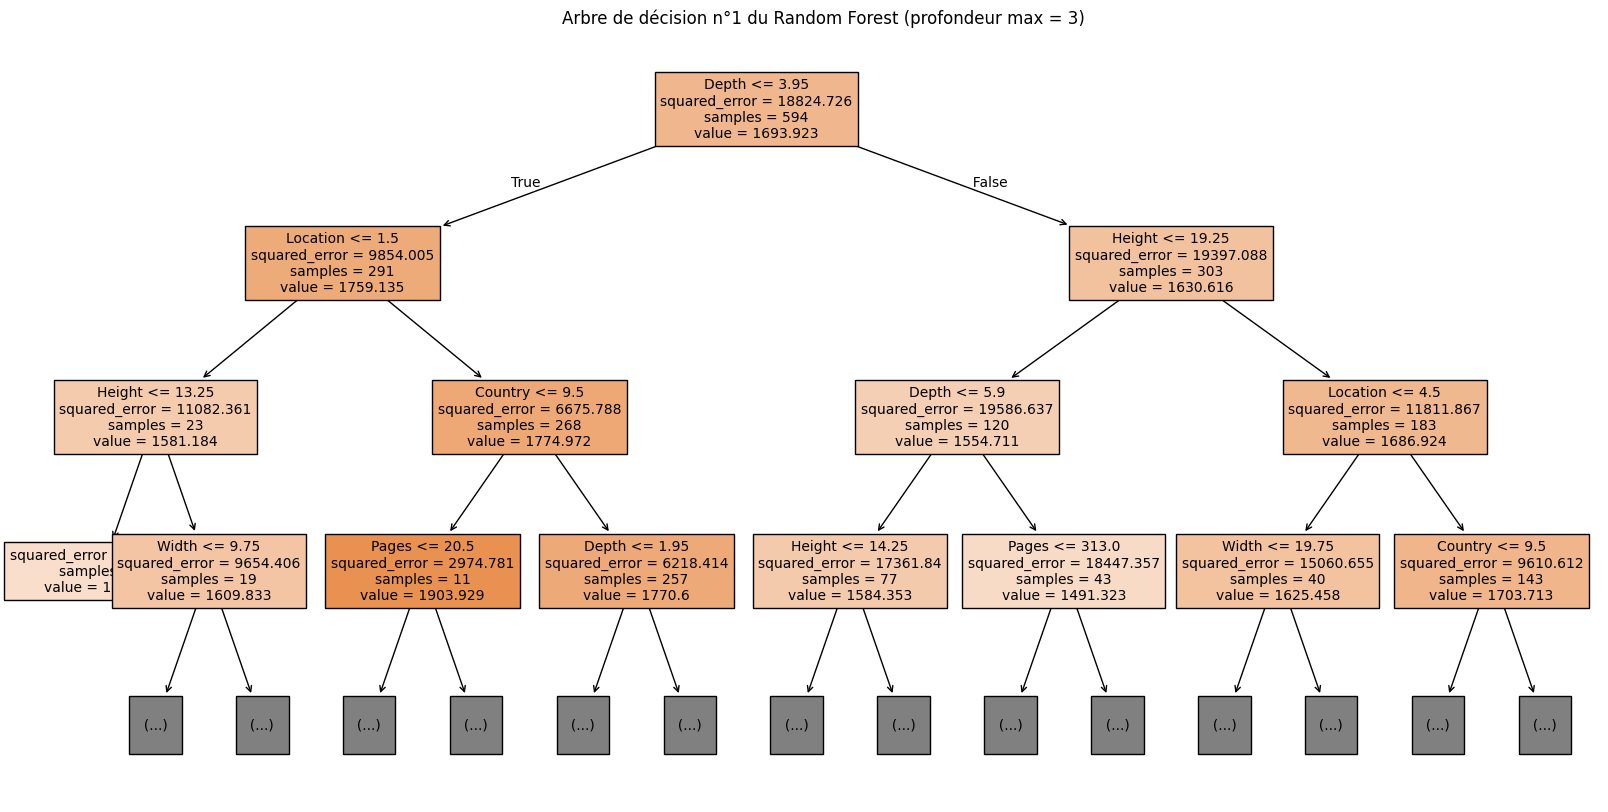

In [22]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(rf_reg.estimators_[0], 
          feature_names=features, 
          filled=True, 
          max_depth=3, 
          fontsize=10)
plt.title("Arbre de décision n°1 du Random Forest (profondeur max = 3)")
plt.show()